In [1]:
import os
os.chdir("./..")

from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", previous_days=5, split="test", continuous=True, countries=["Germany"], installations=[50653])

In [2]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
ADR_fit = ADR(config)
ADR_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\ADR_fix\epoch=17-step=73728.ckpt", weights_only=False)["state_dict"])

W0521 23:34:46.085000 25612 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


<All keys matched successfully>

In [3]:
from models.PVTSMixer import PVTSMixer

config = load_config("./config/TSMixer.yaml")
PVTSMixer_fit = PVTSMixer(config)
PVTSMixer_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\TSMixer_DE50653\epoch=61-step=3906.ckpt", weights_only=False)["state_dict"])
PVTSMixer_fit.eval()

PVTSMixer(
  (criterion): MSELoss()
  (model): TSMixerx(
    (loss): MSELoss()
    (temporal_projection): Linear(in_features=480, out_features=96, bias=True)
    (feature_mixer_hist): FeatureMixing(
      (feature_lin_1): Linear(in_features=8, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=8, out_features=64, bias=True)
      (feature_norm): LayerNorm((96, 64), eps=1e-05, elementwise_affine=True)
    )
    (feature_mixer_futr): FeatureMixing(
      (feature_lin_1): Linear(in_features=7, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=7, out_features=64, bias=True)
      (feature

In [4]:
from models.PVTSMixerADRAugment import PVTSMixerADRAugment

config = load_config("./config/TSMixerADRAugment.yaml")
PVTSMixerADRAugment_fit = PVTSMixerADRAugment(config)
PVTSMixerADRAugment_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\TSMixerADRAugment\epoch=91-step=47104.ckpt", weights_only=False)["state_dict"])
PVTSMixerADRAugment_fit.eval()

PVTSMixerADRAugment(
  (criterion): MSELoss()
  (ADR): ADRModule()
  (model): TSMixerx(
    (loss): MSELoss()
    (temporal_projection): Linear(in_features=480, out_features=96, bias=True)
    (feature_mixer_hist): FeatureMixing(
      (feature_lin_1): Linear(in_features=9, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=9, out_features=64, bias=True)
      (feature_norm): LayerNorm((96, 64), eps=1e-05, elementwise_affine=True)
    )
    (feature_mixer_futr): FeatureMixing(
      (feature_lin_1): Linear(in_features=8, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=8, out_feature

In [5]:
from models.PVTSMixerADRResidual import PVTSMixerADRResidual

config = load_config("./config/TSMixerADRResidual.yaml")
PVTSMixerADRResidual_fit = PVTSMixerADRResidual(config)
PVTSMixerADRResidual_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\TSMixerADRResidual_DE50653\epoch=28-step=1827.ckpt", weights_only=False)["state_dict"])
PVTSMixerADRResidual_fit.eval()

PVTSMixerADRResidual(
  (criterion): MSELoss()
  (ADR): ADRModule()
  (model): TSMixerx(
    (loss): MSELoss()
    (temporal_projection): Linear(in_features=480, out_features=96, bias=True)
    (feature_mixer_hist): FeatureMixing(
      (feature_lin_1): Linear(in_features=9, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=9, out_features=64, bias=True)
      (feature_norm): LayerNorm((96, 64), eps=1e-05, elementwise_affine=True)
    )
    (feature_mixer_futr): FeatureMixing(
      (feature_lin_1): Linear(in_features=8, out_features=64, bias=True)
      (feature_lin_2): Linear(in_features=64, out_features=64, bias=True)
      (feature_drop_1): Dropout(p=0.0, inplace=False)
      (feature_drop_2): Dropout(p=0.0, inplace=False)
      (project_residual): Linear(in_features=8, out_featur

In [6]:
for name, param in PVTSMixerADRResidual_fit.ADR.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.245
u0: 25.001
u1: 6.993
k_a: 1.000
k_d: -6.003
tc_d: 0.022
k_rs: 0.008
k_rsh: 0.004


C:\Users\peter\AppData\Local\Temp\ipykernel_25612\1938531830.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)
C:\Users\peter\AppData\Local\Temp\ipykernel_25612\1938531830.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse_PVTSMixer = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVTSMixer), torch.tensor(y))
C:\Users\peter\AppData\Local\Temp\ipykernel_25612\1938531830.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse_PVTSMixerADRAugment = torch.nn.functional.mse_lo

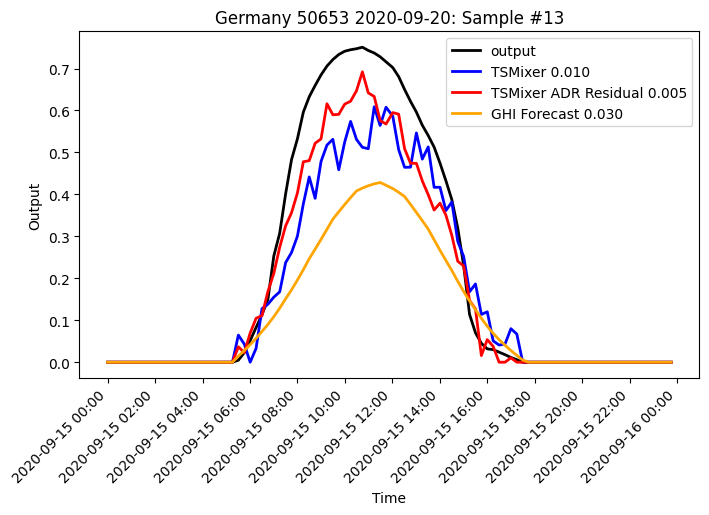

In [37]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from utils.normalize import normalize_inputs

import random

sample = random.randint(0, len(ds)-1)
#sample = 78

x, y, metadata = ds[sample]
timestamps = x['unix_timestamps'][:96].squeeze()
for key in list(x.keys()):
    x[key] = x[key].unsqueeze(0)
    # if key != 'ghi':
    #     del x[key]

for key in list(metadata.keys()):
    if isinstance(metadata[key], str):
        continue
    metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)

x_copy = {k: v.clone() for k, v in x.items()}

y_hat = PVTSMixer_fit(x.copy(), metadata).squeeze()
y_hat_PVTSMixer = y_hat.detach().numpy()

y_hat = PVTSMixerADRAugment_fit(x.copy(), metadata).squeeze()
y_hat_PVTSMixerADRAugment = y_hat.detach().numpy()

y_hat = PVTSMixerADRResidual_fit(x.copy(), metadata).squeeze()
y_hat_PVTSMixerADRResidual = y_hat.detach().numpy()

y_hat_ADR = ADR_fit(x_copy, metadata)
y_hat_ADR = y_hat_ADR.detach().numpy()

ghi = x.copy()['ghi'][:,-96:].squeeze() / 1000

y_hat_PVTSMixer[ghi == 0] = 0
y_hat_PVTSMixer[y_hat_PVTSMixer < 0] = 0

y_hat_PVTSMixerADRResidual[ghi == 0] = 0
y_hat_PVTSMixerADRResidual[y_hat_PVTSMixerADRResidual < 0] = 0

mse_PVTSMixer = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVTSMixer), torch.tensor(y))
mse_PVTSMixerADRAugment = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVTSMixerADRAugment), torch.tensor(y))
mse_PVTSMixerADRResidual = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVTSMixerADRResidual), torch.tensor(y))
mse_GHI = torch.nn.functional.mse_loss(torch.tensor(ghi), torch.tensor(y))
mse_ADR = torch.nn.functional.mse_loss(torch.tensor(y_hat_ADR[0][-96:]), torch.tensor(y))

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(timestamps, unit="s"), y, label="output", color="black", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_PVTSMixer, label=f"TSMixer {mse_PVTSMixer:.3f}", color="blue", linewidth=2)
#ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_PVTSMixerADRAugment, label=f"TSMixer ADR Augment {mse_PVTSMixerADRAugment:.3f}", color="purple", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_PVTSMixerADRResidual, label=f"TSMixer ADR Residual {mse_PVTSMixerADRResidual:.3f}", color="red", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), ghi, label=f"GHI Forecast {mse_GHI:.3f}", color="orange", linewidth=2)
#ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_ADR[0][-96:], label=f"ADR {mse_ADR:.3f}", color="green", linewidth=2)
#ax.plot(pd.to_datetime(timestamps, unit="s"), x['solar_zenith'][0][-96:] - 1.6, label=f"Solar Zenith", color="brown", linewidth=1)
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45, ha='right')
#ax.set_ylim(0,1)
plt.title(f"{metadata['country']} {metadata['installation'][0]} {metadata['date']}: Sample #{sample}")
plt.show()

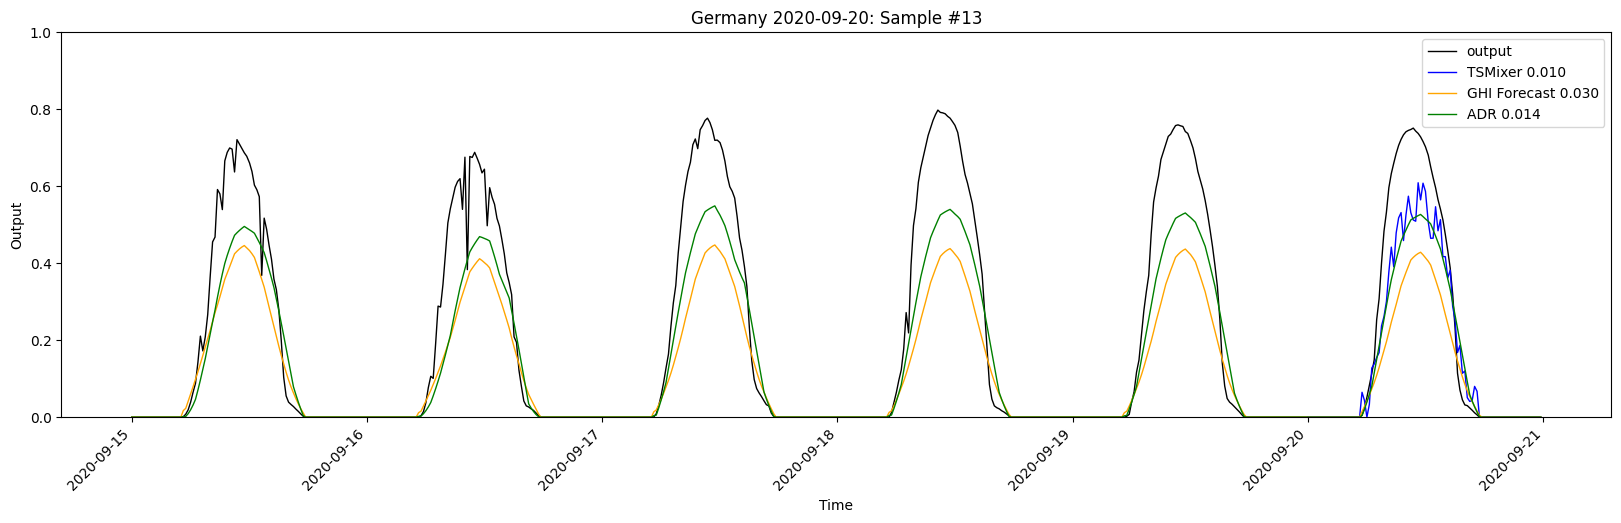

In [51]:
ghi = x_copy['ghi'].squeeze() / 1000

production = torch.cat((x_copy['production'].squeeze(), y.squeeze()))

timestamps = x_copy['unix_timestamps'].squeeze()

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(pd.to_datetime(timestamps, unit="s"), production, label="output", color="black", linewidth=1)
ax.plot(pd.to_datetime(timestamps[-96:], unit="s"), y_hat_PVTSMixer, label=f"TSMixer {mse_PVTSMixer:.3f}", color="blue", linewidth=1)
ax.plot(pd.to_datetime(timestamps, unit="s"), ghi, label=f"GHI Forecast {mse_GHI:.3f}", color="orange", linewidth=1)
ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_ADR[0], label=f"ADR {mse_ADR:.3f}", color="green", linewidth=1)
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0,1)
plt.title(f"{metadata['country']} {metadata['date']}: Sample #{sample}")
plt.show()

In [10]:
#sample = random.randint(0, len(ds)-1)
x, y, metadata = ds[sample]
for key in list(x.keys()):
    x[key] = x[key].unsqueeze(0)
for key in list(metadata.keys()):
    if isinstance(metadata[key], str):
        continue
    metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)
y_hat_ADR_TSMixer = PVTSMixerADRResidual_fit.ADR(x, metadata).squeeze().detach().numpy()

y_hat = PVTSMixerADRResidual_fit(x, metadata).squeeze()
y_hat_PVTSMixerADRResidual_fit = y_hat.detach().numpy()

C:\Users\peter\AppData\Local\Temp\ipykernel_25612\3408250843.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)


C:\Users\peter\AppData\Local\Temp\ipykernel_25612\2369960697.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)
C:\Users\peter\AppData\Local\Temp\ipykernel_25612\2369960697.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.plot(pd.to_datetime(timestamps, unit="s"), production - y_hat_ADR_TSMixer, label="ADR residuals", color="black", linewidth=1)


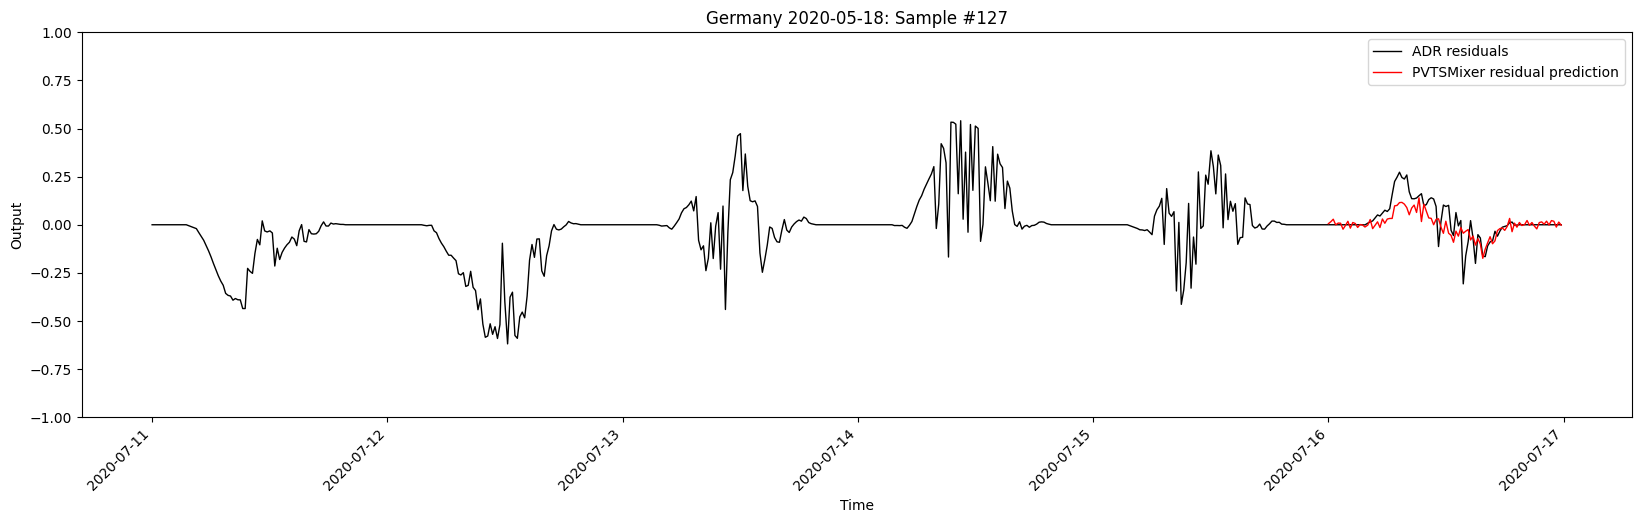

In [11]:
sample = random.randint(0, len(ds)-1)
x, y, metadata = ds[sample]
for key in list(x.keys()):
    x[key] = x[key].unsqueeze(0)
for key in list(metadata.keys()):
    if isinstance(metadata[key], str):
        continue
    metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)
y_hat_ADR_TSMixer = PVTSMixerADRResidual_fit.ADR(x, metadata).squeeze().detach().numpy()

y_hat = PVTSMixerADRResidual_fit(x, metadata).squeeze()
y_hat_PVTSMixerADRResidual_fit = y_hat.detach().numpy()

production = torch.cat((x_copy['production'].squeeze(), y.squeeze()))

timestamps = x_copy['unix_timestamps'].squeeze()

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(pd.to_datetime(timestamps, unit="s"), production - y_hat_ADR_TSMixer, label="ADR residuals", color="black", linewidth=1)
#ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_ADR_TSMixer, label="ADR predictions", color="blue", linewidth=1)
ax.plot(pd.to_datetime(timestamps[-96:], unit="s"), y_hat_PVTSMixerADRResidual_fit - y_hat_ADR_TSMixer[-96:], label="PVTSMixer residual prediction", color="red", linewidth=1)
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(-1,1)
plt.title(f"{metadata['country']} {metadata['date']}: Sample #{sample}")
plt.show()

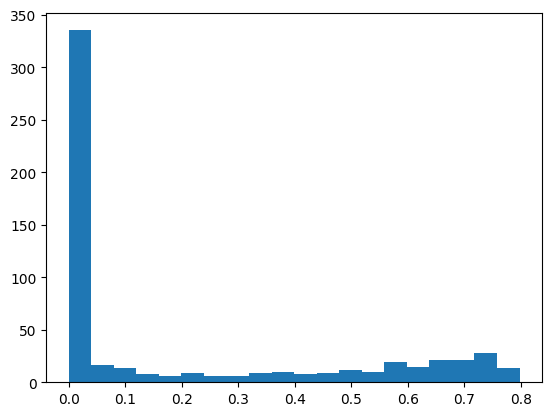

In [64]:
import numpy as np

plt.hist(production, bins=20)
plt.show()

C:\Users\peter\AppData\Local\Temp\ipykernel_25612\3410652310.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.hist(np.log10(production * 1000 + 1e-2), bins=20)


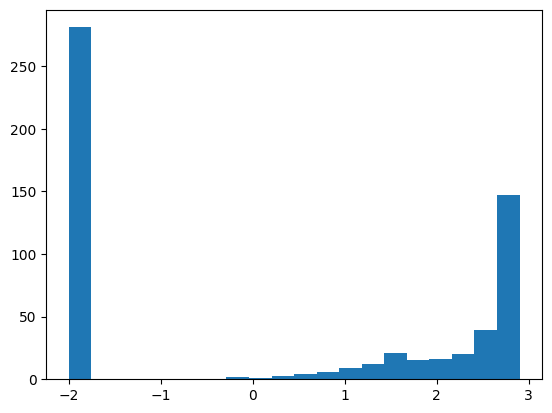

In [65]:
plt.hist(np.log10(production * 1000 + 1e-2), bins=20)
plt.show()